In [1]:
# Cell 1 — Imports and path setup
"""
01_prepare_data.ipynb
=====================
Download all data sources, merge, split, and create DataLoaders.
Run this once before training.
"""

import sys
sys.path.insert(0, "../src")

from tgnn_solv.data import (
    load_bigsoldb,
    load_melting_points,
    load_fusion_enthalpies,
    load_hansen,
    load_idac,
    DataBuilder,
    filter_for_sle,
    scaffold_split,
    make_loaders,
    PROCESSED_DIR,
)

print("All imports OK")

All imports OK


In [2]:
# Cell 2 — Load primary source
bigsoldb = load_bigsoldb()
print(f"\nShape: {bigsoldb.shape}")
bigsoldb.head()

,solute_smiles,solvent_smiles,temperature,ln_x2,source,solute_name,solvent_name,fda_approved
0,CCCCCCCCCCCCCCCCCCCC(=O)OCCO,CCO,311.25,-7.418581,BigSolDBv2.1,Ethylene glycol monoeicosate,ethanol,No
1,CCCCCCCCCCCCCCCCCCCC(=O)OCCO,CCO,314.65,-6.725434,BigSolDBv2.1,Ethylene glycol monoeicosate,ethanol,No
2,CCCCCCCCCCCCCCCCCCCC(=O)OCCO,CCO,319.15,-6.214608,BigSolDBv2.1,Ethylene glycol monoeicosate,ethanol,No
3,CCCCCCCCCCCCCCCCCCCC(=O)OCCO,CCO,322.15,-5.298317,BigSolDBv2.1,Ethylene glycol monoeicosate,ethanol,No
4,CCCCCCCCCCCCCCCCCCCC(=O)OCCO,CCO,324.15,-4.275866,BigSolDBv2.1,Ethylene glycol monoeicosate,ethanol,No


In [3]:
# Cell 3 — Filter for SLE compatibility
bigsoldb = filter_for_sle(bigsoldb, x2_max=0.98)
print(f"After SLE filter: {len(bigsoldb):,}")

  SLE filter: 108287 → 101763 (misc: -0, struct: -6524, self: -0)
After SLE filter: 101,763


In [4]:
# Cell 4 — Load auxiliary sources
mp_data = load_melting_points()
dh_data = load_fusion_enthalpies()
hansen_data = load_hansen()
idac_data = load_idac()

  Bradley valid: 19,042
  Curated: 32, overrides: 31
  Total: 19,043
  T_m range: [159, 800] K

Loading ΔH_fus data
  Records: 31

Loading Hansen parameters
  Records: 43

Loading IDAC data
  Records: 31


In [5]:
# Cell 5 — Build unified dataset
builder = DataBuilder()
builder.add_mp(mp_data)
builder.add_dh(dh_data)
builder.add_hansen(hansen_data)
builder.add_gamma(idac_data)

unified = builder.build(bigsoldb)
print(f"\nUnified shape: {unified.shape}")
unified.head()

,solute_smiles,solvent_smiles,temperature,ln_x2,source,solute_name,solvent_name,fda_approved,has_solubility,T_m,has_T_m,dH_fus,has_dH_fus,hansen_d,hansen_p,hansen_h,has_hansen,ln_gamma_inf,has_gamma_inf
0,CCCCCCCCCCCCCCCCCCCC(=O)OCCO,CCO,311.25,-7.418581,BigSolDBv2.1,Ethylene glycol monoeicosate,ethanol,No,True,0.0,False,0.0,False,0.0,0.0,0.0,False,0.0,False
1,CCCCCCCCCCCCCCCCCCCC(=O)OCCO,CCO,314.65,-6.725434,BigSolDBv2.1,Ethylene glycol monoeicosate,ethanol,No,True,0.0,False,0.0,False,0.0,0.0,0.0,False,0.0,False
2,CCCCCCCCCCCCCCCCCCCC(=O)OCCO,CCO,319.15,-6.214608,BigSolDBv2.1,Ethylene glycol monoeicosate,ethanol,No,True,0.0,False,0.0,False,0.0,0.0,0.0,False,0.0,False
3,CCCCCCCCCCCCCCCCCCCC(=O)OCCO,CCO,322.15,-5.298317,BigSolDBv2.1,Ethylene glycol monoeicosate,ethanol,No,True,0.0,False,0.0,False,0.0,0.0,0.0,False,0.0,False
4,CCCCCCCCCCCCCCCCCCCC(=O)OCCO,CCO,324.15,-4.275866,BigSolDBv2.1,Ethylene glycol monoeicosate,ethanol,No,True,0.0,False,0.0,False,0.0,0.0,0.0,False,0.0,False


In [14]:
# Cell — Data quality check
import matplotlib.pyplot as plt

sol_data = unified[unified["has_solubility"]]

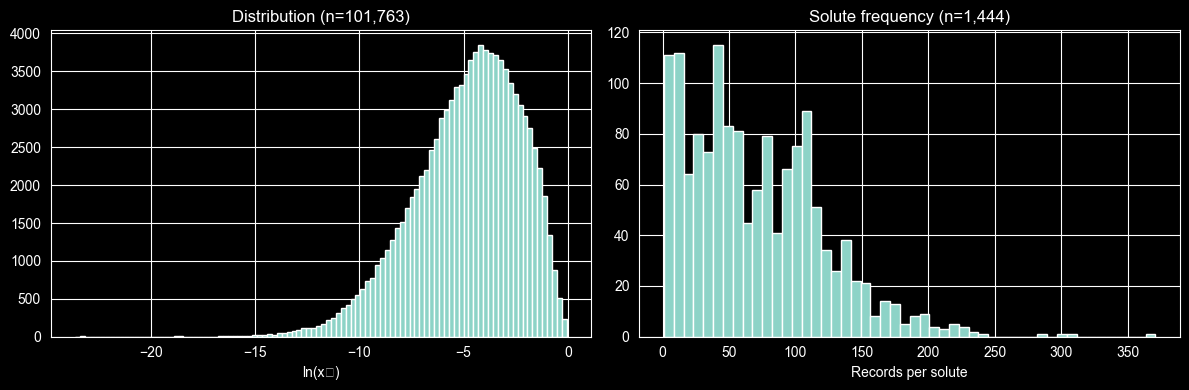

In [15]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].hist(sol_data["ln_x2"], bins=100, edgecolor="white")
axes[0].set_xlabel("ln(x₂)")
axes[0].set_title(f"Distribution (n={len(sol_data):,})")

sol_counts = sol_data["solute_smiles"].value_counts()
axes[1].hist(sol_counts.values, bins=50, edgecolor="white")
axes[1].set_xlabel("Records per solute")
axes[1].set_title(f"Solute frequency (n={len(sol_counts):,})")

plt.tight_layout()
plt.show()

In [16]:
print(f"\nSolutes with only 1 record: "
      f"{(sol_counts == 1).sum()} / {len(sol_counts)}")
print(f"Solutes with >50 records: "
      f"{(sol_counts > 50).sum()}")
non_298 = (sol_data["temperature"] - 298.15).abs() > 1
print(f"\nRecords at T≠298K: {non_298.sum()} ({non_298.sum()/len(sol_data)*100:.1f}%)")


Solutes with only 1 record: 12 / 1444
Solutes with >50 records: 813

Records at T≠298K: 91522 (89.9%)


In [6]:
# Cell 6 — Scaffold split
train_df, val_df, test_df = scaffold_split(unified)

# Save to CSV
train_df.to_csv(PROCESSED_DIR / "train.csv", index=False)
val_df.to_csv(PROCESSED_DIR / "val.csv", index=False)
test_df.to_csv(PROCESSED_DIR / "test.csv", index=False)
print(f"Saved to {PROCESSED_DIR}/")

Saved to data/processed/


In [7]:
# Cell 7 — Create DataLoaders (smoke test)
train_loader, val_loader, test_loader = make_loaders(
    train_df, val_df, test_df, batch_size=64,
)

# Verify one batch
for sol_b, slv_b, tgt in train_loader:
    B = tgt["T"].shape[0]
    print(f"Batch B={B}")
    print(f"  Solute atoms:    {sol_b.x.shape[0]}")
    print(f"  Solvent atoms:   {slv_b.x.shape[0]}")
    print(f"  has_solubility:  {tgt['has_solubility'].sum()}/{B}")
    print(f"  T_m_mask:        {tgt['T_m_mask'].sum()}/{B}")
    print(f"  dH_mask:         {tgt['dH_mask'].sum()}/{B}")
    print(f"  hansen_mask:     {tgt['hansen_mask'].sum()}/{B}")
    print(f"  gamma_mask:      {tgt['gamma_mask'].sum()}/{B}")
    break

print("\nData pipeline complete!")

  Dataset: 7,787 valid (0 dropped, 2412 cached graphs)
  Train: 104,625 samples, 1,634 batches
  Val: 7,785 samples, 122 batches
  Test: 7,787 samples, 122 batches
Batch B=64
  Solute atoms:    1104
  Solvent atoms:   256
  has_solubility:  60/64
  T_m_mask:        41/64
  dH_mask:         0/64
  hansen_mask:     0/64
  gamma_mask:      0/64

Data pipeline complete!
